<a href="https://colab.research.google.com/github/lalamiranda/Framework-Basinet/blob/main/Framework_Basinet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/lalamiranda/Framework-Basinet.git

Cloning into 'Framework-Basinet'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 16 (delta 2), reused 14 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 459.68 KiB | 1.71 MiB/s, done.
Resolving deltas: 100% (2/2), done.


/tmp/ipykernel_6580/2177300177.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='DENV', y='Tamanho', data=df, palette='Set2')


Text(0, 0.5, 'Tamanho da Sequência (Nucleotídeos)')

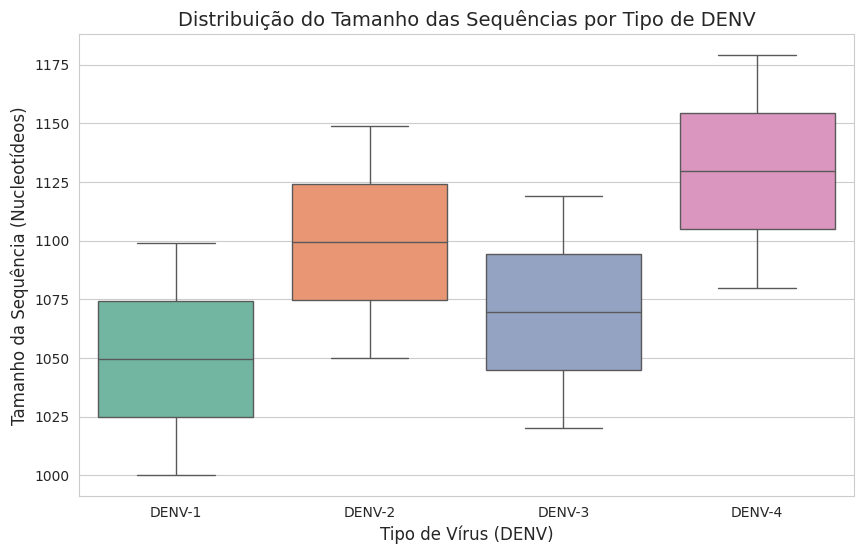

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Preparando os dados
# Substitua as listas abaixo pelos tamanhos REAIS das suas sequências
dados = {
    'DENV': (
        ['DENV-1'] * 100 + ['DENV-2'] * 100 +
        ['DENV-3'] * 100 + ['DENV-4'] * 100
    ),
    'Tamanho': (
        # Exemplo: tamanhos hipotéticos para cada grupo
        [len_seq for len_seq in range(1000, 1100)] + # DENV-1
        [len_seq for len_seq in range(1050, 1150)] + # DENV-2
        [len_seq for len_seq in range(1020, 1120)] + # DENV-3
        [len_seq for len_seq in range(1080, 1180)]   # DENV-4
    )
}

df = pd.DataFrame(dados)

# 2. Configurações visuais
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# 3. Criando o Boxplot
# Escolhi uma paleta de cores para diferenciar bem os 4 tipos
ax = sns.boxplot(x='DENV', y='Tamanho', data=df, palette='Set2')

# 4. Detalhes do gráfico
plt.title('Distribuição do Tamanho das Sequências por Tipo de DENV', fontsize=14)
plt.xlabel('Tipo de Vírus (DENV)', fontsize=12)
plt.ylabel('Tamanho da Sequência (Nucleotídeos)', fontsize=12)

In [ ]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 41.8 MB/s eta 0:00:00


Processando DENV-1...
Processando DENV-2...
Processando DENV-3...
Processando DENV-4...

--- RESULTADOS TOPOLÓGICOS ---

DENV-1:
  Hubs de Convergência (In): [('TGG', 50), ('AGA', 49), ('TGA', 47)]
  Hubs de Divergência (Out): [('CAC', 48), ('AGC', 47), ('AAT', 46)]

DENV-2:
  Hubs de Convergência (In): [('ATG', 51), ('GGA', 50), ('AGA', 49)]
  Hubs de Divergência (Out): [('GGA', 54), ('ACA', 53), ('AAA', 51)]

DENV-3:
  Hubs de Convergência (In): [('AGA', 50), ('CAT', 49), ('AGC', 49)]
  Hubs de Divergência (Out): [('AAA', 51), ('AGA', 50), ('GAA', 47)]

DENV-4:
  Hubs de Convergência (In): [('TGG', 52), ('CAG', 46), ('CAA', 46)]
  Hubs de Divergência (Out): [('GAG', 54), ('CCA', 52), ('TGG', 50)]


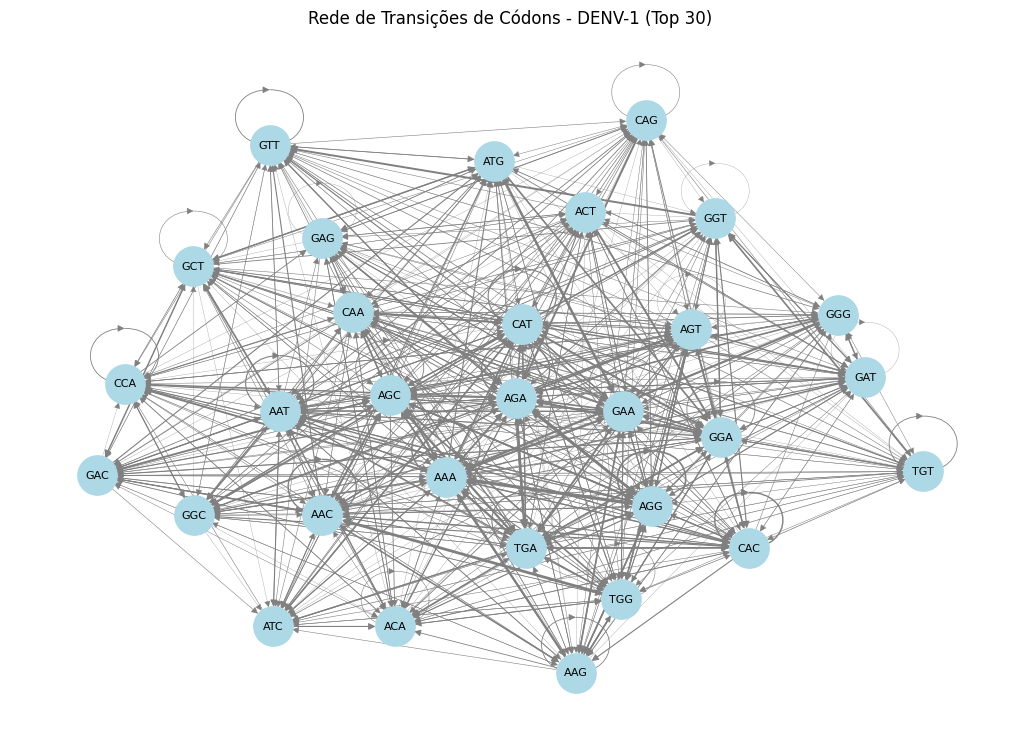

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import os
from Bio import SeqIO

# 1. CONFIGURAÇÃO DE CAMINHOS
# Se o comando !ls mostrou que os arquivos estão em uma pasta específica, mude aqui:
caminho_base = "/content/Framework-Basinet/"

# Mapeamento dos arquivos conforme os nomes no repositório (ajuste se necessário)
arquivos = {
    "DENV-1": "DENV-1.fasta",
    "DENV-2": "DENV-2.fasta",
    "DENV-3": "DENV-3.fasta",
    "DENV-4": "DENV-4.fasta"
}

def processar_denv(nome_sorotipo, nome_arquivo):
    caminho_completo = os.path.join(caminho_base, nome_arquivo)

    # Leitura do arquivo
    record = SeqIO.read(caminho_completo, "fasta")
    seq = str(record.seq)

    # Segmentação em Códons (WS=3, ST=3)
    limite = (len(seq) // 3) * 3
    codons = [seq[i:i+3] for i in range(0, limite, 3)]

    # Construção da Rede Direcionada
    G = nx.DiGraph()
    for i in range(len(codons) - 1):
        c1, c2 = codons[i], codons[i+1]
        if G.has_edge(c1, c2):
            G[c1][c2]['weight'] += 1
        else:
            G.add_edge(c1, c2, weight=1)

    return G, codons

# 2. PROCESSAMENTO
resultados = {}
for soro, arq in arquivos.items():
    try:
        print(f"Processando {soro}...")
        g, c = processar_denv(soro, arq)
        resultados[soro] = {"grafo": g, "codons": c}
    except Exception as e:
        print(f"Erro ao processar {soro}: {e}")

# 3. EXTRAÇÃO DAS MÉTRICAS (Hubs de Convergência e Divergência)
print("\n--- RESULTADOS TOPOLÓGICOS ---")
for soro, dados in resultados.items():
    G = dados["grafo"]
    in_deg = sorted(G.in_degree(), key=lambda x: x[1], reverse=True)[:3]
    out_deg = sorted(G.out_degree(), key=lambda x: x[1], reverse=True)[:3]

    print(f"\n{soro}:")
    print(f"  Hubs de Convergência (In): {in_deg}")
    print(f"  Hubs de Divergência (Out): {out_deg}")

# 4. VISUALIZAÇÃO (Exemplo DENV-1)
if "DENV-1" in resultados:
    plt.figure(figsize=(10,7))
    G_plot = resultados["DENV-1"]["grafo"]
    # Pegar os 30 nós mais frequentes para o gráfico não travar
    nodes = pd.Series(resultados["DENV-1"]["codons"]).value_counts().head(30).index
    sub = G_plot.subgraph(nodes)

    pos = nx.spring_layout(sub, k=0.5)
    nx.draw(sub, pos, with_labels=True, node_color='lightblue',
            node_size=800, font_size=8, edge_color='gray',
            width=[d['weight']*0.2 for u,v,d in sub.edges(data=True)])
    plt.title("Rede de Transições de Códons - DENV-1 (Top 30)")
    plt.show()

In [ ]:
from Bio import SeqIO

def extrair_tamanhos(arquivo):
    tamanhos = []

    for record in SeqIO.parse(arquivo, "fasta"):
        tamanho = len(record.seq)
        tamanhos.append(tamanho)

    return tamanhos

# lendo os arquivos
tamanhos_denv1 = extrair_tamanhos("Framework-Basinet/DENV-1.fasta")
tamanhos_denv2 = extrair_tamanhos("Framework-Basinet/DENV-2.fasta")
tamanhos_denv3 = extrair_tamanhos("Framework-Basinet/DENV-3.fasta")
tamanhos_denv4 = extrair_tamanhos("Framework-Basinet/DENV-4.fasta")

print("DENV-1:", tamanhos_denv1[:5])
print("DENV-2:", tamanhos_denv2[:5])
print("DENV-3:", tamanhos_denv3[:5])
print("DENV-4:", tamanhos_denv4[:5])

DENV-1: [10735]
DENV-2: [10723]
DENV-3: [10707]
DENV-4: [10649]


In [ ]:
import pandas as pd

dados = {
    'DENV': (
        ['DENV-1'] * len(tamanhos_denv1) +
        ['DENV-2'] * len(tamanhos_denv2) +
        ['DENV-3'] * len(tamanhos_denv3) +
        ['DENV-4'] * len(tamanhos_denv4)
    ),
    'Tamanho': (
        tamanhos_denv1 +
        tamanhos_denv2 +
        tamanhos_denv3 +
        tamanhos_denv4
    )
}

df = pd.DataFrame(dados)

print(df.head())

     DENV  Tamanho
0  DENV-1    10735
1  DENV-2    10723
2  DENV-3    10707
3  DENV-4    10649


/tmp/ipykernel_149/3099428802.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DENV', y='Tamanho', data=df, palette='Set2')


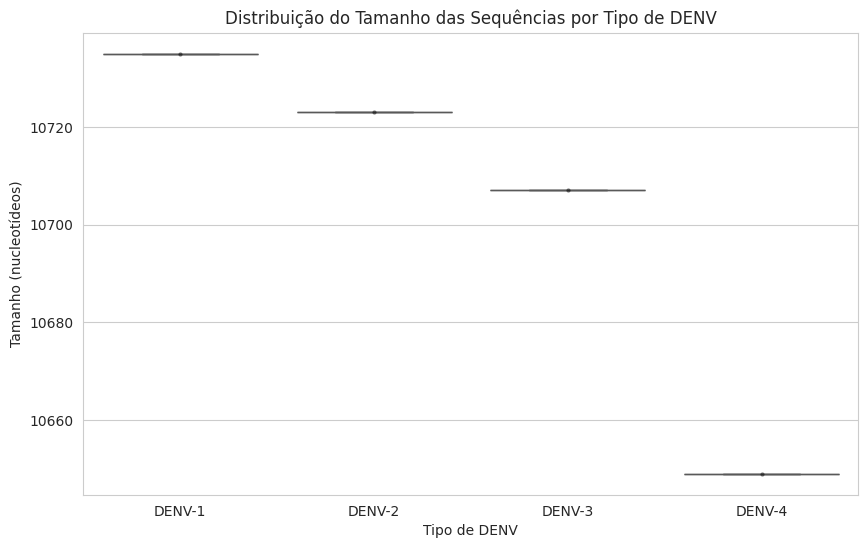

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.set_style("whitegrid")

sns.boxplot(x='DENV', y='Tamanho', data=df, palette='Set2')

sns.stripplot(
    x='DENV',
    y='Tamanho',
    data=df,
    color='black',
    size=3,
    alpha=0.5
)

plt.title('Distribuição do Tamanho das Sequências por Tipo de DENV')
plt.xlabel('Tipo de DENV')
plt.ylabel('Tamanho (nucleotídeos)')

plt.show()

In [ ]:
print(df.groupby('DENV')['Tamanho'].describe())

        count     mean  std      min      25%      50%      75%      max
DENV                                                                    
DENV-1    1.0  10735.0  NaN  10735.0  10735.0  10735.0  10735.0  10735.0
DENV-2    1.0  10723.0  NaN  10723.0  10723.0  10723.0  10723.0  10723.0
DENV-3    1.0  10707.0  NaN  10707.0  10707.0  10707.0  10707.0  10707.0
DENV-4    1.0  10649.0  NaN  10649.0  10649.0  10649.0  10649.0  10649.0


In [ ]:
from Bio import SeqIO
import pandas as pd
import matplotlib.pyplot as plt

def contar_bases(arquivo):
    contagem = {'A':0, 'T':0, 'C':0, 'G':0}

    for record in SeqIO.parse(arquivo, "fasta"):
        seq = str(record.seq)
        for base in seq:
            if base in contagem:
                contagem[base] += 1

    return contagem

# aplicar pra cada DENV
dados = []

arquivos = {
    "DENV-1": "/content/Framework-Basinet/DENV-1.fasta",
    "DENV-2": "/content/Framework-Basinet/DENV-2.fasta",
    "DENV-3": "/content/Framework-Basinet/DENV-3.fasta",
    "DENV-4": "/content/Framework-Basinet/DENV-4.fasta"
}

for denv, arq in arquivos.items():
    cont = contar_bases(arq)
    for base, valor in cont.items():
        dados.append([denv, base, valor])

df_bases = pd.DataFrame(dados, columns=["DENV", "Base", "Quantidade"])

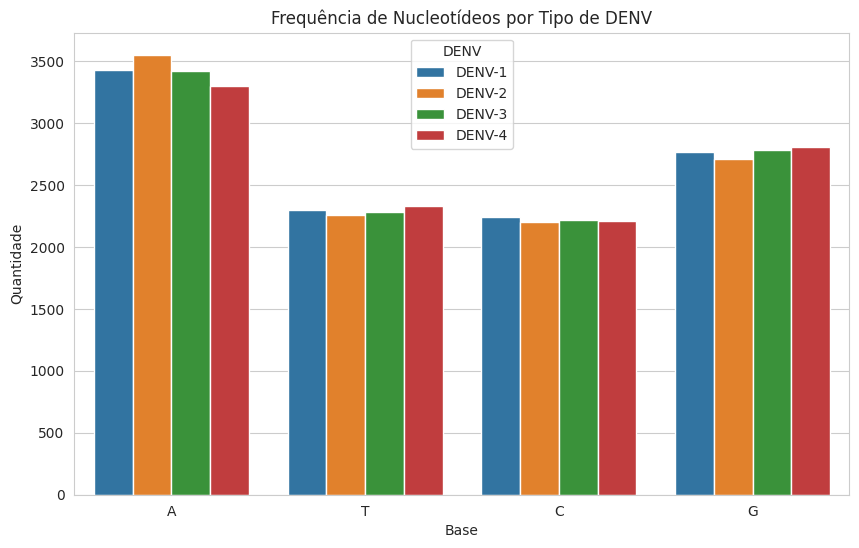

In [ ]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    x="Base",
    y="Quantidade",
    hue="DENV",
    data=df_bases
)

plt.title("Frequência de Nucleotídeos por Tipo de DENV")
plt.savefig("grafico_denv.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
def gc_content(cont):
    total = sum(cont.values())
    return (cont['G'] + cont['C']) / total * 100

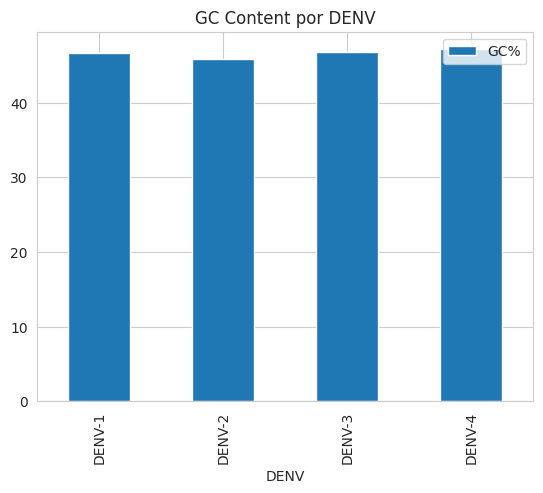

In [ ]:
gc = []

for denv, arq in arquivos.items():
    cont = contar_bases(arq)
    gc.append([denv, gc_content(cont)])

df_gc = pd.DataFrame(gc, columns=["DENV", "GC%"])

df_gc.plot(x="DENV", y="GC%", kind="bar")
plt.title("GC Content por DENV")
plt.savefig("grafico_denv.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from Bio import SeqIO
from collections import Counter
import pandas as pd

def contar_codons(arquivo):
    contagem = Counter()

    for record in SeqIO.parse(arquivo, "fasta"):
        seq = str(record.seq)

        limite = (len(seq) // 3) * 3
        codons = [seq[i:i+3] for i in range(0, limite, 3)]

        contagem.update(codons)

    return contagem

In [ ]:
arquivos = {
    "DENV-1": "/content/Framework-Basinet/DENV-1.fasta",
    "DENV-2": "/content/Framework-Basinet/DENV-2.fasta",
    "DENV-3": "/content/Framework-Basinet/DENV-3.fasta",
    "DENV-4": "/content/Framework-Basinet/DENV-4.fasta"
}

dados = []

for denv, arq in arquivos.items():
    cont = contar_codons(arq)

    for codon, freq in cont.items():
        dados.append([denv, codon, freq])

df_codons = pd.DataFrame(dados, columns=["DENV", "Codon", "Frequencia"])

In [ ]:
top_codons = (
    df_codons.groupby("Codon")["Frequencia"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

df_top = df_codons[df_codons["Codon"].isin(top_codons)]

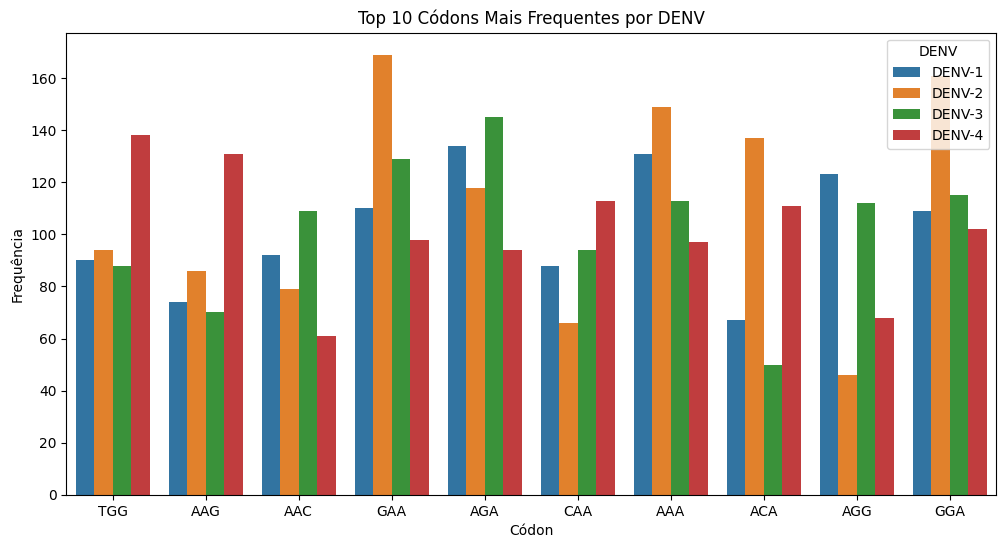

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(
    x="Codon",
    y="Frequencia",
    hue="DENV",
    data=df_top
)

plt.title("Top 10 Códons Mais Frequentes por DENV")
plt.xlabel("Códon")
plt.ylabel("Frequência")

plt.show()